# Customer churn prediction: Telecom Churn Dataset

Customer churn, also known as customer retention, customer turnover, or customer defection, is the loss of clients or customers.

Telephone service companies, Internet service providers, pay TV companies, insurance firms, and alarm monitoring services, often use customer attrition analysis and customer attrition rates as one of their key business metrics  because the cost of retaining an existing customer is far less than acquiring a new one. Companies from these sectors often have customer service branches which attempt to win back defecting clients, because recovered long-term customers can be worth much more to a company than newly recruited clients.

Companies usually make a distinction between voluntary churn and involuntary churn. Voluntary churn occurs due to a decision by the customer to switch to another company or service provider, involuntary churn occurs due to circumstances such as a customer's relocation to a long-term care facility, death, or the relocation to a distant location. In most applications, involuntary reasons for churn are excluded from the analytical models. Analysts tend to concentrate on voluntary churn, because it typically occurs due to factors of the company-customer relationship which companies control, such as how billing interactions are handled or how after-sales help is provided.

predictive analytics  use churn prediction models that predict customer churn by assessing their propensity of risk to churn. Since these models generate a small prioritized list of potential defectors, they are effective at focusing customer retention marketing programs on the subset of the customer base who are most vulnerable to churn.

**Please upvote for this kernel as well as the Telecom Churn Dataset if you find them useful.**

- <a href='#1'>1. Data overview</a>
- <a href='#2'>2. Exploratory Data Analysis</a>
    - <a href='#2.1'>2.1. Customer churn in data</a>
    - <a href='#2.2'>2.2. Variable distributions</a>
- <a href='#3'>3. Data preprocessing</a>
    - <a href='#3.1'>3.1. Variable summary</a>
    - <a href='#3.2'>3.2. Correlation matrix</a>
    - <a href='#3.3'>3.3. Visualizing data with principal components</a>
    - <a href='#3.4'>3.4. Binary variable distributions in customer churn (Radar Chart)</a>
- <a href='#4'>4. Model Building</a>
    - <a href='#4.1'>4.1. Baseline model</a>
    - <a href='#4.2'>4.2. Random Forest Classifier</a>
    - <a href='#4.3'>4.3. XGBoost Classifier</a>
    - <a href='#4.4'>4.4. GradientBoosting Classifier</a>
- <a href='#5'>5. Model performances over the training dataset</a>
    - <a href='#5.1'>5.1. Model performance metrics</a>
    - <a href='#5.2'>5.2. Compare model metrics</a>
    - <a href='#5.3'>5.3. Confusion matrices for models</a>
    - <a href='#5.4'>5.4. ROC - Curves for models</a>
    - <a href='#5.5'>5.5. Precision recall curves</a>
- <a href='#6'>6. Model performances over the principal test dataset</a>
    - <a href='#6.1'>6.1. Model performance metrics</a>
    - <a href='#6.2'>6.2. Compare model metrics</a>
    - <a href='#6.3'>6.3. Confusion matrices for models</a>
    - <a href='#6.4'>6.4. ROC - Curves for models</a>
    - <a href='#6.5'>6.5. Precision recall curves</a>
- <a href='#7'>7. Conclusiones</a>

In [ ]:
#Importing libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from math import * # module math
import matplotlib.pyplot as plt # visualization
import seaborn as sns # visualization
import itertools
import plotly.offline as py # visualization
py.init_notebook_mode(connected=True) # visualization
import plotly.graph_objs as go # visualization
from plotly.subplots import make_subplots
import plotly.figure_factory as ff # visualization
import warnings
warnings.filterwarnings("ignore")
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

%matplotlib inline

# <a id='1'>1. Data overview</a>

In [ ]:
telcom = pd.read_csv(r"../data/raw/churn-bigml-train.csv")
telcom_test = pd.read_csv(r"../data/raw/churn-bigml-test.csv")
telcom.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [163]:
len(telcom), len(telcom_test)*4

(2589, 2592)

In [164]:
def dataoveriew(df, message):
    print(f'{message}:\n')
    print("Rows:", df.shape[0])
    print("\nNumber of features:", df.shape[1])
    print("\nFeatures:")
    print(telcom.columns.tolist())
    print("\nMissing values:", df.isnull().sum().values.sum())
    print("\nUnique values:")
    print(df.nunique())

In [165]:
dataoveriew(telcom, 'Overiew of the training dataset')

Overiew of the training dataset:

Rows: 2589

Number of features: 20

Features:
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

Missing values: 0

Unique values:
State                       51
Account length             205
Area code                    3
International plan           2
Voice mail plan              2
Number vmail messages       42
Total day minutes         1464
Total day calls            115
Total day charge          1464
Total eve minutes         1421
Total eve calls            120
Total eve charge          1283
Total night minutes       1422
Total night calls          118
Total night charge         877
Total intl minutes         15

In [166]:
dataoveriew(telcom_test, 'Overiew of the test dataset')

Overiew of the test dataset:

Rows: 648

Number of features: 20

Features:
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

Missing values: 0

Unique values:
State                      51
Account length            178
Area code                   3
International plan          2
Voice mail plan             2
Number vmail messages      37
Total day minutes         550
Total day calls            99
Total day charge          550
Total eve minutes         546
Total eve calls            93
Total eve charge          521
Total night minutes       554
Total night calls          95
Total night charge        444
Total intl minutes        132
Total intl calls   

# <a id='2'>2. Exploratory Data Analysis</a>

## <a id='2.1'>2.1. Customer churn in data</a>

In [167]:
trace = go.Pie(labels = telcom["Churn"].value_counts().keys().tolist(),
               values = telcom["Churn"].value_counts().values.tolist(),
               marker = dict(colors = ['royalblue','lime'],
                             line = dict(color = "white", width =  1.3)
                            ),
               rotation = 90,
               hoverinfo = "label+value+text",
               hole = .5
              )
layout = go.Layout(dict(title = "Customer churn in training data",
                        plot_bgcolor = "rgb(243,243,243)",
                        paper_bgcolor = "rgb(243,243,243)",
                       )
                  )
data = [trace]
fig = go.Figure(data = data, layout = layout)
py.iplot(fig)

## <a id='2.2'>2.2. Variable distributions</a>

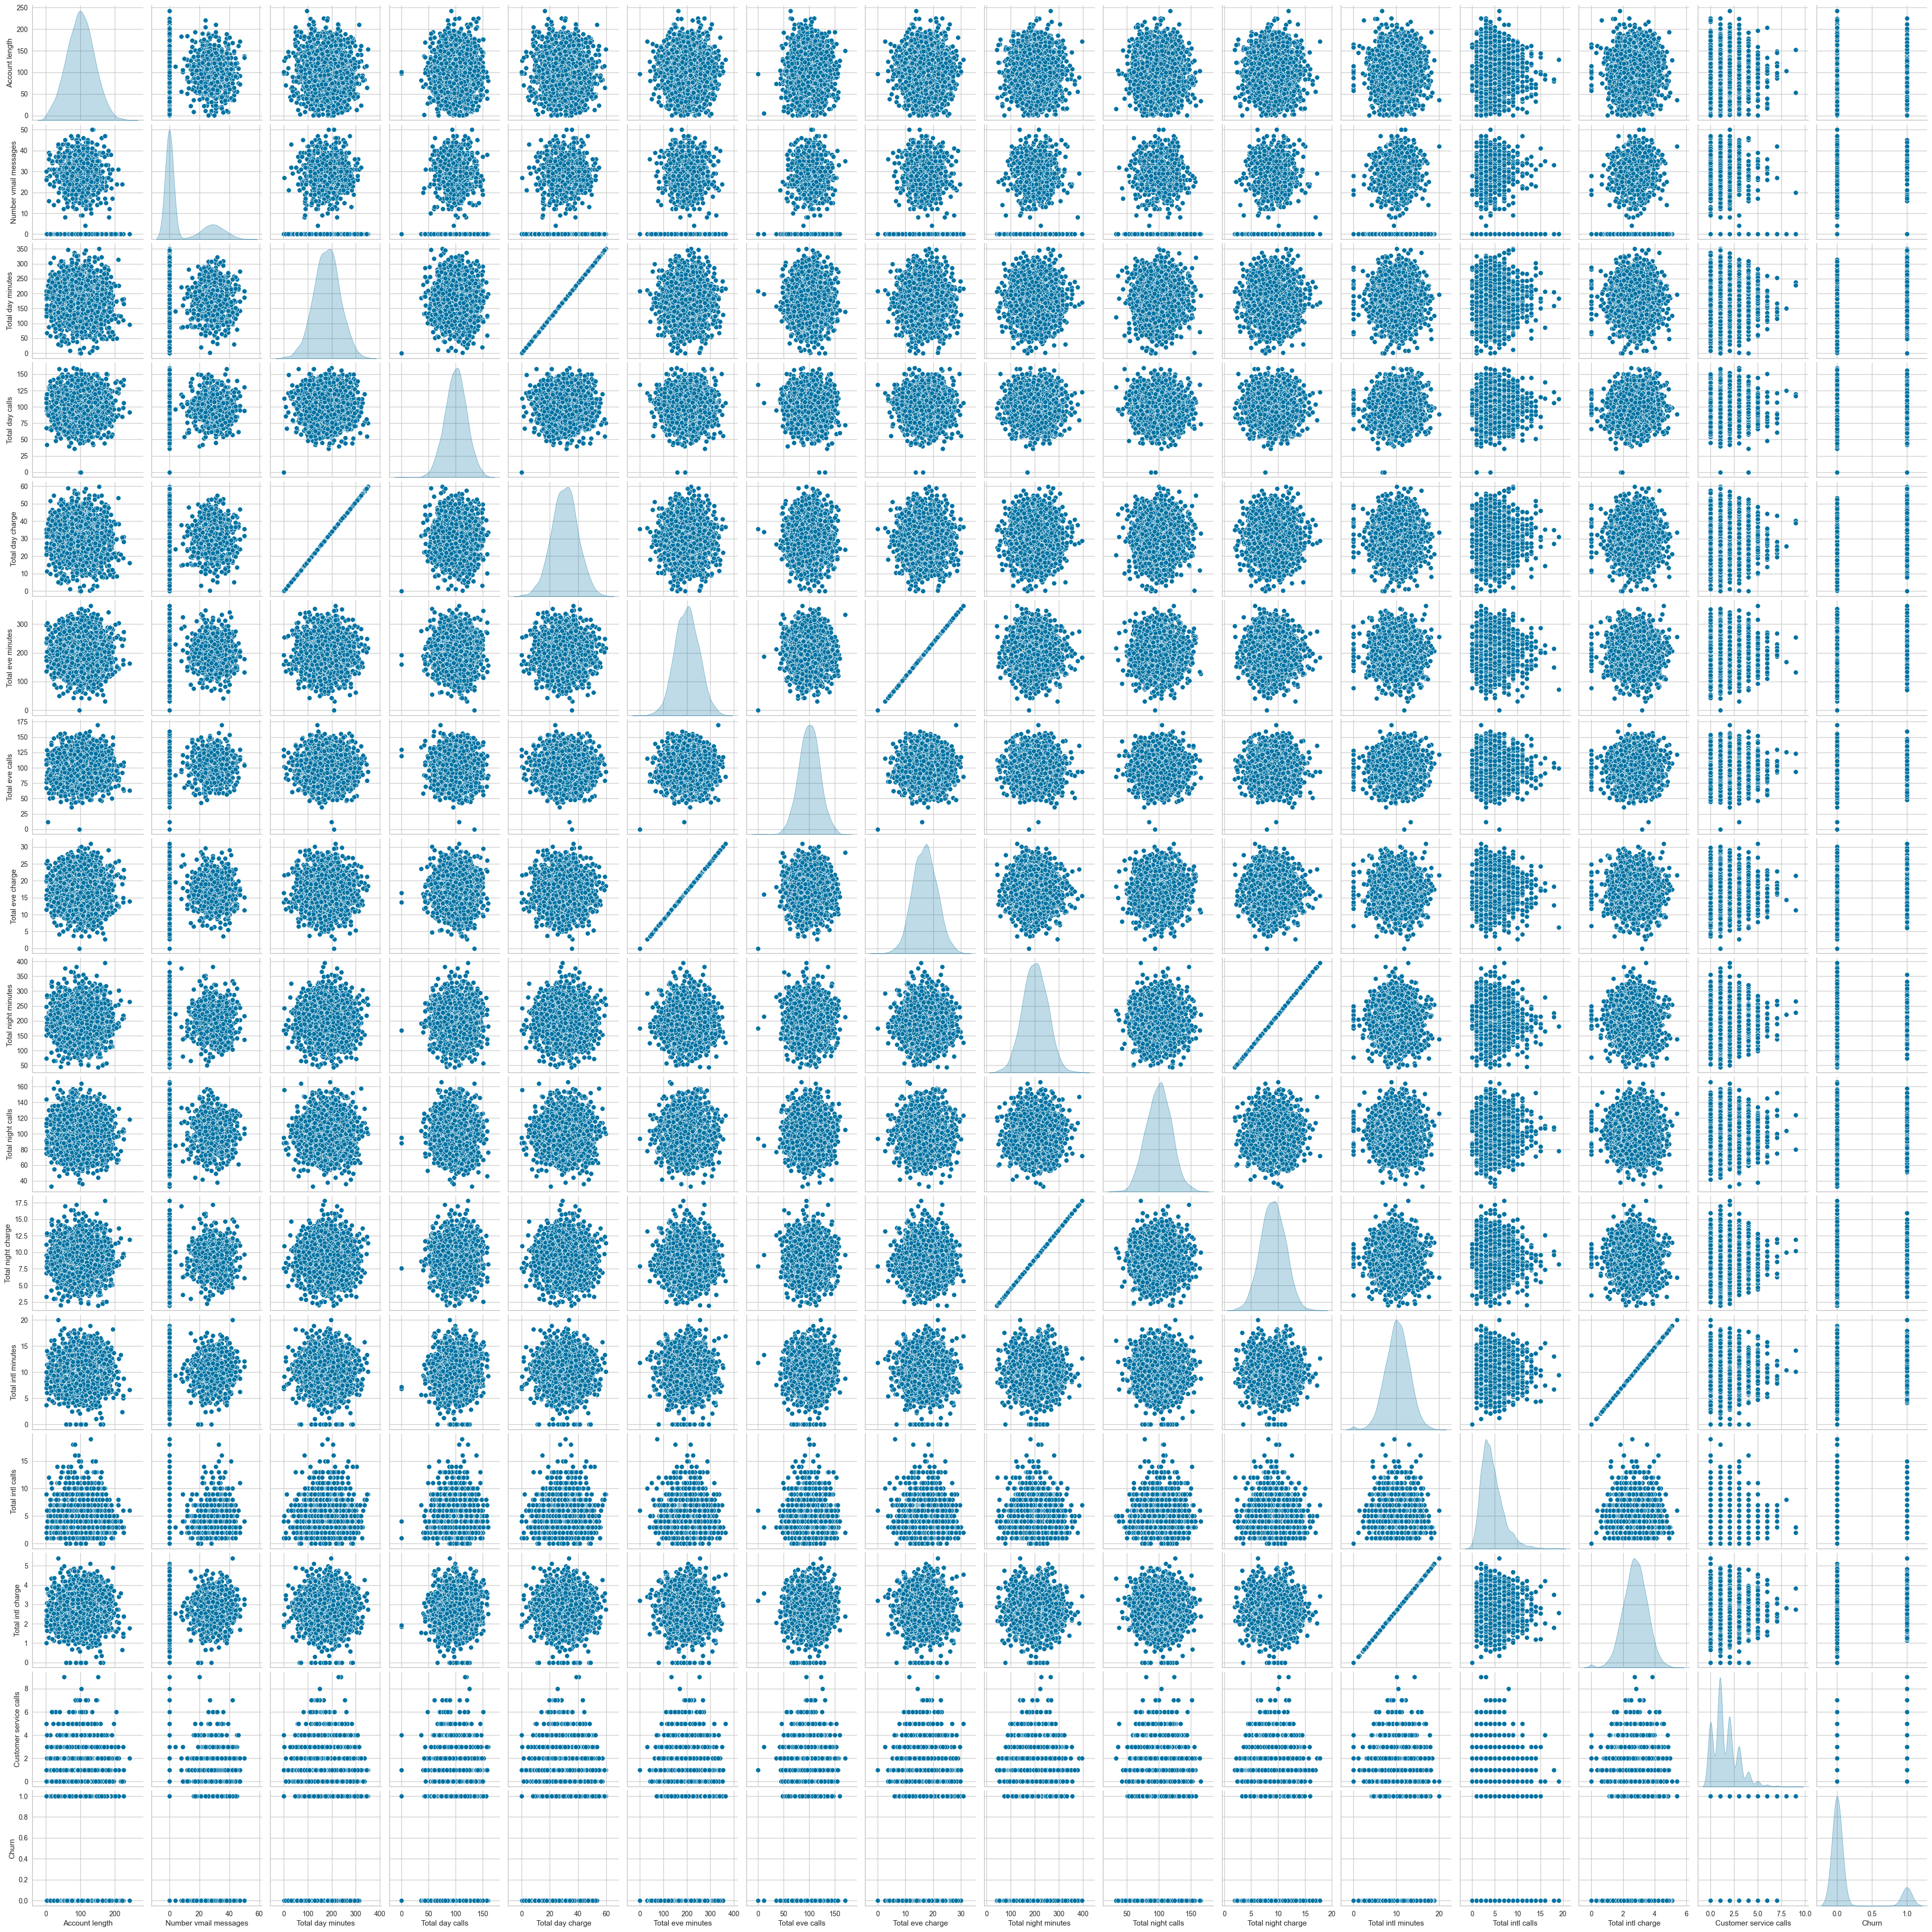

In [168]:
#Separating columns to be visualized
out_cols = list(set(telcom.nunique()[telcom.nunique()<6].keys().tolist()
                    + telcom.select_dtypes(include='object').columns.tolist()))
viz_cols = [x for x in telcom.columns if x not in out_cols] + ['Churn']

sns.pairplot(telcom[viz_cols], diag_kind="kde")
plt.show()

Several of the numerical data are very correlated. (Total day minutes and Total day charge), (Total eve minutes and Total eve charge), (Total night minutes and Total night charge) and lastly (Total intl minutes and Total intl charge) are alo correlated. We only have to select one of them.

# <a id='3'>3. Data preprocessing</a>

In [169]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

#Removing correlated and unneccessary columns
col_to_drop = ['State', 'Area code', 'Total day charge', 'Total eve charge', 
               'Total night charge', 'Total intl charge']
   
telcom = telcom.drop(columns = col_to_drop, axis = 1)
telcom_test = telcom_test.drop(columns = col_to_drop, axis = 1)

#target column
target_col = ["Churn"]

#number of levels in feature to be a categorical feature
nlevels = 6

#Separating categorical and numerical columns
#categorical columns
cat_cols = list(set(telcom.nunique()[telcom.nunique()<nlevels].keys().tolist() 
                    + telcom.select_dtypes(include='object').columns.tolist()))
cat_cols = [x for x in cat_cols if x not in target_col]
#numerical columns
num_cols = [x for x in telcom.columns if x not in cat_cols + target_col]
#Binary columns with 2 values
bin_cols = telcom.nunique()[telcom.nunique() == 2].keys().tolist()
#Columns more than 2 values
multi_cols = [i for i in cat_cols if i not in bin_cols]

#Label encoding Binary columns
le = LabelEncoder()
for i in bin_cols:
    telcom[i] = le.fit_transform(telcom[i])
    telcom_test[i] = le.transform(telcom_test[i])

#combining the train and test datasets
trainsize = telcom.shape[0]
comb = pd.concat((telcom, telcom_test), sort=False)

#Duplicating columns for multi value columns
comb = pd.get_dummies(data = comb, columns = multi_cols)

#Separating the train and test datasets
telcom = comb[:trainsize]
telcom_test = comb[trainsize:]

#Scaling Numerical columns
std = StandardScaler()
scaled = std.fit_transform(telcom[num_cols])
scaled = pd.DataFrame(scaled, columns=num_cols)

scaled_test = std.transform(telcom_test[num_cols])
scaled_test = pd.DataFrame(scaled_test, columns=num_cols)

#dropping original values merging scaled values for numerical columns
df_telcom_og = telcom.copy()
telcom = telcom.drop(columns = num_cols, axis = 1)
telcom = telcom.merge(scaled, left_index=True, right_index=True, how = "left")

df_telcom_test_og = telcom_test.copy()
telcom_test = telcom_test.drop(columns = num_cols, axis = 1)
telcom_test = telcom_test.merge(scaled_test, left_index=True, right_index=True, how = "left")

## <a id='3.1'>3.1. Variable summary</a>

In [170]:
summary = (df_telcom_og[[i for i in df_telcom_og.columns]].
           describe().transpose().reset_index())

summary = summary.rename(columns = {"index" : "feature"})
summary = np.around(summary,3)

val_lst = [summary['feature'], summary['count'],
           summary['mean'],summary['std'],
           summary['min'], summary['25%'],
           summary['50%'], summary['75%'], summary['max']]

trace  = go.Table(header = dict(values = summary.columns.tolist(),
                                line = dict(color = ['#506784']),
                                fill = dict(color = ['#119DFF']),
                               ),
                  cells  = dict(values = val_lst,
                                line = dict(color = ['#506784']),
                                fill = dict(color = ["lightgrey",'#F5F8FF'])
                               ),
                  columnwidth = [200,60,100,100,60,60,80,80,80])
layout = go.Layout(dict(title = "Training variable Summary"))
figure = go.Figure(data=[trace],layout=layout)
py.iplot(figure)

## <a id='3.2'>3.2. Correlation matrix</a>

In [171]:
#correlation
correlation = telcom.corr()
#tick labels
matrix_cols = correlation.columns.tolist()
#convert to array
corr_array = np.array(correlation)

#Plotting
trace = go.Heatmap(z = corr_array,
                   x = matrix_cols,
                   y = matrix_cols,
                   colorscale = "Viridis",
                   colorbar = dict(title = "Pearson Correlation coefficients", titleside = "right"),
                  )
layout = go.Layout(dict(title = "Correlation matrix",
                        autosize = False,
                        height = 720,
                        width = 800,
                        margin = dict(r = 0, l = 210, t = 25, b = 210),
                        yaxis = dict(tickfont = dict(size = 9)),
                        xaxis = dict(tickfont = dict(size = 9))
                       )
                  )
data = [trace]
fig = go.Figure(data=data, layout=layout)
py.iplot(fig)

## <a id='3.3'>3.3. Visualizing data with principal components</a>

In [172]:
def pca_scatter(pcadf, targetfeature, targetlabel, color):
    tracer = go.Scatter(x = pcadf[pcadf[targetfeature]==targetlabel]["PC1"],
                        y = pcadf[pcadf[targetfeature]==targetlabel]["PC2"],
                        name = targetlabel, mode = "markers",
                        marker = dict(color = color, line = dict(width = .5), symbol = "diamond-open"),
                       )
    return tracer

In [173]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

X = telcom[[i for i in telcom.columns if i not in target_col]]
Y = telcom[target_col]

principal_components = pca.fit_transform(X)
pca_data = pd.DataFrame(principal_components, columns = ["PC1", "PC2"])
pca_data = pca_data.merge(Y, left_index=True, right_index=True, how="left")
pca_data["Churn"] = pca_data["Churn"].replace({1: "Churn", 0: "Not churn"})

layout = go.Layout(dict(title = "Visualizing data with PCA",
                        plot_bgcolor = "rgb(243,243,243)",
                        paper_bgcolor = "rgb(243,243,243)",
                        xaxis = dict(gridcolor = 'rgb(255, 255, 255)',
                                     title = "first principal component (PC1)",
                                     zerolinewidth=1, ticklen=5, gridwidth=2),
                        yaxis = dict(gridcolor = 'rgb(255, 255, 255)',
                                     title = "second principal component (PC2)",
                                     zerolinewidth=1, ticklen=5, gridwidth=2),
                        height = 400
                       )
                  )
trace1 = pca_scatter(pca_data, 'Churn', 'Churn', 'red')
trace2 = pca_scatter(pca_data, 'Churn', 'Not churn', 'royalblue')
data = [trace2, trace1]
fig = go.Figure(data=data, layout=layout)
py.iplot(fig)

## <a id='3.4'>3.4. Binary variable distribution in customer churn (Radar Chart)</a>

In [174]:
def plot_radar(df, aggregate, title):
    data_frame = df[df["Churn"] == aggregate] 
    data_frame_x = data_frame[bi_cs].sum().reset_index()
    data_frame_x.columns = ["feature", "yes"]
    data_frame_x["no"] = data_frame.shape[0] - data_frame_x["yes"]
    data_frame_x = data_frame_x[data_frame_x["feature"] != "Churn"]
    
    #count of 1's (yes)
    trace1 = go.Scatterpolar(r = data_frame_x["yes"].values.tolist(),
                             theta = data_frame_x["feature"].tolist(),
                             fill = "toself", 
                             name = "count of 1's",
                             mode = "markers+lines",
                             marker = dict(size = 5)
                            )
    #count of 0's (no)
    trace2 = go.Scatterpolar(r = data_frame_x["no"].values.tolist(),
                             theta = data_frame_x["feature"].tolist(),
                             fill = "toself", 
                             name = "count of 0's",
                             mode = "markers+lines",
                             marker = dict(size = 5)
                            ) 
    layout = go.Layout(dict(polar = dict(radialaxis = dict(visible = True,
                                                           side = "counterclockwise",
                                                           showline = True,
                                                           linewidth = 2,
                                                           tickwidth = 2,
                                                           gridcolor = "white",
                                                           gridwidth = 2),
                                         angularaxis = dict(tickfont = dict(size = 10),
                                                            layer = "below traces"
                                                           ),
                                         bgcolor = "rgb(243,243,243)",
                                        ),
                            paper_bgcolor = "rgb(243,243,243)",
                            title = title, height = 600, width = 600))
    
    data = [trace2, trace1]
    fig = go.Figure(data=data, layout=layout)
    py.iplot(fig)

In [175]:
#separating binary columns
bi_cs = telcom.nunique()[telcom.nunique() == 2].keys()
dat_rad = telcom[bi_cs]

#plotting radar chart for churn and not churn customers (binary variables)
plot_radar(dat_rad, 1, "Churn customers")
plot_radar(dat_rad, 0, "Not churn customers")

# <a id='4'>4. Model Building</a>

In [176]:
def telecom_churn_prediction(algorithm, training_x, testing_x, training_y, testing_y, cf, threshold_plot):
    #model
    algorithm.fit(training_x, training_y)
    predictions = algorithm.predict(testing_x)
    probabilities = algorithm.predict_proba(testing_x)
        
    print('Algorithm:', type(algorithm).__name__)
    print("\nClassification report:\n", classification_report(testing_y, predictions))
    print("Accuracy Score:", accuracy_score(testing_y, predictions))
    
    #confusion matrix
    conf_matrix = confusion_matrix(testing_y, predictions)
    #roc_auc_score
    model_roc_auc = roc_auc_score(testing_y, predictions) 
    print("Area under curve:", model_roc_auc,"\n")
    
    fpr, tpr, thresholds = roc_curve(testing_y, probabilities[:,1])
     
    #plot confusion matrix
    trace1 = go.Heatmap(z = conf_matrix,
                        x = ["Not churn", "Churn"],
                        y = ["Not churn", "Churn"],
                        showscale = False, colorscale = "Picnic",
                        name = "Confusion matrix")
    
    #plot roc curve
    trace2 = go.Scatter(x = fpr, y = tpr,
                        name = "Roc: " + str(model_roc_auc),
                        line = dict(color = ('rgb(22, 96, 167)'), width = 2))
    trace3 = go.Scatter(x = [0,1], y = [0,1],
                        line = dict(color = ('rgb(205, 12, 24)'), width = 2,
                        dash = 'dot'))
    
    if cf in ['coefficients', 'features']:
        if cf == 'coefficients':
            coefficients = pd.DataFrame(algorithm.coef_.ravel())
        elif cf == 'features':
            coefficients = pd.DataFrame(algorithm.feature_importances_)
        
        column_df = pd.DataFrame(training_x.columns.tolist())
        coef_sumry = (pd.merge(coefficients, column_df, left_index=True, 
                               right_index=True, how="left"))
        coef_sumry.columns = ["coefficients", "features"]
        coef_sumry = coef_sumry.sort_values(by = "coefficients", ascending=False)
        
        #plot coeffs
        trace4 = go.Bar(x = coef_sumry["features"], y = coef_sumry["coefficients"], 
                        name = "coefficients",
                        marker = dict(color = coef_sumry["coefficients"],
                                      colorscale = "Picnic",
                                      line = dict(width = .6, color = "black")
                                     )
                       )
        #subplots
        fig = make_subplots(rows=2, cols=2, specs=[[{}, {}], [{'colspan': 2}, None]],
                                subplot_titles=('Confusion matrix',
                                                'Receiver operating characteristic',
                                                'Feature importances')
                           )  
        fig.append_trace(trace1,1,1)
        fig.append_trace(trace2,1,2)
        fig.append_trace(trace3,1,2)
        fig.append_trace(trace4,2,1)
        fig['layout'].update(showlegend=False, title="Model performance",
                             autosize=False, height = 900, width = 800,
                             plot_bgcolor = 'rgba(240,240,240, 0.95)',
                             paper_bgcolor = 'rgba(240,240,240, 0.95)',
                             margin = dict(b = 195))
        fig["layout"]["xaxis2"].update(dict(title = "false positive rate"))
        fig["layout"]["yaxis2"].update(dict(title = "true positive rate"))
        fig["layout"]["xaxis3"].update(dict(showgrid = True, tickfont = dict(size = 10), tickangle = 90))
        
    elif cf == 'None':
        #subplots
        fig = make_subplots(rows=1, cols=2,
                            subplot_titles=('Confusion matrix',
                                            'Receiver operating characteristic')
                           )
        fig.append_trace(trace1,1,1)
        fig.append_trace(trace2,1,2)
        fig.append_trace(trace3,1,2)
        fig['layout'].update(showlegend=False, title="Model performance",
                         autosize=False, height = 500, width = 800,
                         plot_bgcolor = 'rgba(240,240,240,0.95)',
                         paper_bgcolor = 'rgba(240,240,240,0.95)',
                         margin = dict(b = 195))
        fig["layout"]["xaxis2"].update(dict(title = "false positive rate"))
        fig["layout"]["yaxis2"].update(dict(title = "true positive rate"))  
        
    py.iplot(fig)
    
    if threshold_plot == True: 
        visualizer = DiscriminationThreshold(algorithm)
        visualizer.fit(training_x,training_y)
        visualizer.poof()

In [177]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, precision_score, recall_score
from sklearn.metrics import precision_recall_curve, average_precision_score

import statsmodels.api as sm
from yellowbrick.classifier import DiscriminationThreshold

#defining the studied or used independent features (columns) as well the target  
cols = [i for i in telcom.columns if i not in target_col]
target_col = ['Churn']

#splitting the principal training dataset to subtrain and subtest datasets
x_train, x_test, y_train, y_test = train_test_split(telcom[cols], telcom[target_col], 
                                                    test_size = .25, random_state = 111)

#splitting the no scaled principal training dataset to subtrain and subtest datasets
x_train_og, x_test_og, y_train_og, y_test_og = train_test_split(df_telcom_og[cols], telcom[target_col],
                                                                test_size = .25, random_state = 111)

In [178]:
telcom[cols].head()

,International plan,Voice mail plan,Account length,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls
0,0,1,0.692369,1.243937,1.578124,0.484401,-0.054518,-0.052156,0.855254,-0.470714,-0.078650,-0.597356,-0.425598
1,0,1,0.162210,1.317341,-0.331037,1.134176,-0.091772,0.146130,1.046289,0.146547,1.251054,-0.597356,-0.425598
2,0,0,0.919580,-0.591178,1.177846,0.684332,-1.548589,0.493131,-0.761650,0.197985,0.711985,0.223969,-1.188141
3,1,0,-0.418441,-0.591178,2.210822,-1.464923,-2.711298,-0.597444,-0.086135,-0.573591,-1.300539,1.045293,0.336944
4,1,0,-0.645652,-0.591178,-0.236962,0.634349,-1.017233,1.087991,-0.283078,1.072439,-0.042712,-0.597356,1.099487


In [179]:
telcom.head()

,International plan,Voice mail plan,Churn,Account length,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls
0,0,1,0,0.692369,1.243937,1.578124,0.484401,-0.054518,-0.052156,0.855254,-0.470714,-0.078650,-0.597356,-0.425598
1,0,1,0,0.162210,1.317341,-0.331037,1.134176,-0.091772,0.146130,1.046289,0.146547,1.251054,-0.597356,-0.425598
2,0,0,0,0.919580,-0.591178,1.177846,0.684332,-1.548589,0.493131,-0.761650,0.197985,0.711985,0.223969,-1.188141
3,1,0,0,-0.418441,-0.591178,2.210822,-1.464923,-2.711298,-0.597444,-0.086135,-0.573591,-1.300539,1.045293,0.336944
4,1,0,0,-0.645652,-0.591178,-0.236962,0.634349,-1.017233,1.087991,-0.283078,1.072439,-0.042712,-0.597356,1.099487


## <a id='4.1'>4.1. Baseline model</a>

Algorithm: LogisticRegression

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92       555
           1       0.53      0.18      0.27        93

    accuracy                           0.86       648
   macro avg       0.70      0.58      0.60       648
weighted avg       0.83      0.86      0.83       648

Accuracy Score: 0.8595679012345679
Area under curve: 0.5778843359488521 



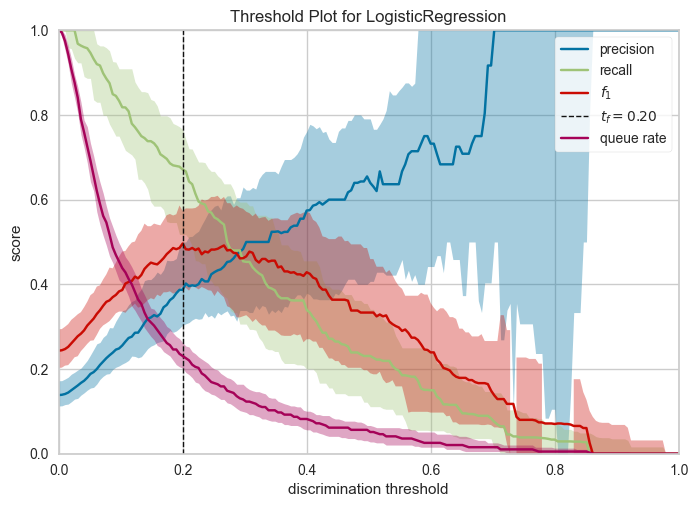

In [180]:
from sklearn.linear_model import LogisticRegression

#Baseline model        
logit = LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                           intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
                           penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
                           verbose=0, warm_start=False)

telecom_churn_prediction(logit, x_train, x_test, y_train, y_test, "coefficients", threshold_plot=True)

## <a id='4.2'>4.2. Random Forest Classifier</a>
Random forest is a meta estimator that fits a number of decision tree classifiers on various sub-samples of the dataset and use averaging to improve the predictive accuracy and control over-fitting. The sub-sample size is always the same as the original input sample size but the samples are drawn with replacement.

Algorithm: RandomForestClassifier

Classification report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96       555
           1       1.00      0.53      0.69        93

    accuracy                           0.93       648
   macro avg       0.96      0.76      0.83       648
weighted avg       0.94      0.93      0.92       648

Accuracy Score: 0.9320987654320988
Area under curve: 0.7634408602150538 



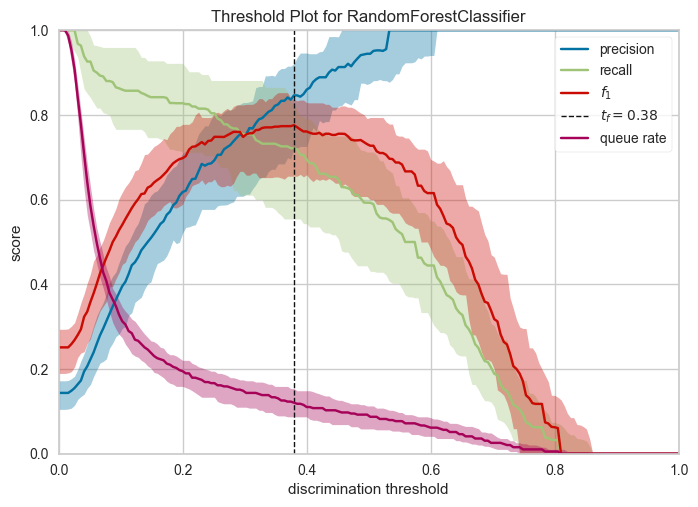

In [181]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators = 100, random_state = 123,
                             max_depth = 9, criterion = "gini")

telecom_churn_prediction(rfc, x_train, x_test, y_train, y_test, 'features', threshold_plot=True)

## <a id='4.3'>4.3. XGBoost  Classifier</a>

Algorithm: XGBClassifier

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       555
           1       0.91      0.68      0.78        93

    accuracy                           0.94       648
   macro avg       0.93      0.83      0.87       648
weighted avg       0.94      0.94      0.94       648

Accuracy Score: 0.9444444444444444
Area under curve: 0.8333042720139493 



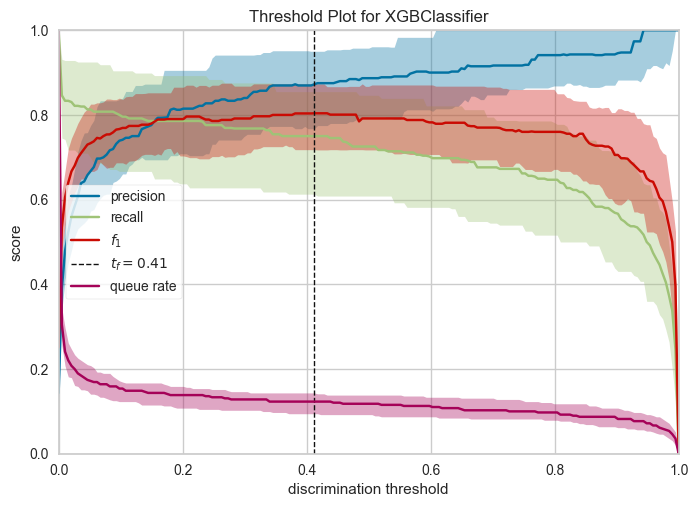

In [182]:
from xgboost import XGBClassifier

xgc = XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
                    colsample_bytree=1, gamma=0, learning_rate=0.9, max_delta_step=0,
                    max_depth=7, min_child_weight=1, n_estimators=100,
                    n_jobs=1, nthread=None, objective='binary:logistic', random_state=0,
                    reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
                    silent=True, subsample=1)

telecom_churn_prediction(xgc, x_train, x_test, y_train, y_test, "features", threshold_plot=True)

## <a id='4.4'>4.4. GradientBoosting Classifier</a> 

Algorithm: GradientBoostingClassifier

Classification report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       555
           1       0.97      0.65      0.77        93

    accuracy                           0.95       648
   macro avg       0.96      0.82      0.87       648
weighted avg       0.95      0.95      0.94       648

Accuracy Score: 0.9459876543209876
Area under curve: 0.8207788433594885 



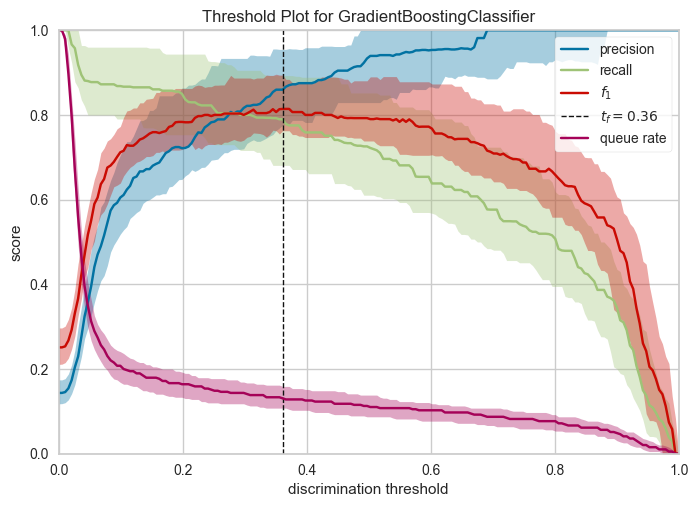

In [183]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(random_state=124)

telecom_churn_prediction(gbc, x_train, x_test, y_train, y_test, "features", threshold_plot=True)

# <a id='5'>5. Model performances over the training dataset</a>

In [ ]:
#putting all the model names, model classes and the used columns in a dictionary
models = {'Logistic (Baseline)': [logit, cols],
          'Random Forest': [rfc, cols], 
          'XGBoost Classifier': [xgc, cols], 
          'GradientBoost': [gbc, cols] 
         }

## <a id='5.1'>5.1. Model performance metrics</a>

In [185]:
#gives model report in dataframe
def model_report(model, training_x, testing_x, training_y, testing_y, name):
    model = model.fit(training_x, training_y)
    predictions = model.predict(testing_x)
    accuracy = accuracy_score(testing_y, predictions)
    recallscore = recall_score(testing_y, predictions)
    precision = precision_score(testing_y, predictions)
    roc_auc = roc_auc_score(testing_y, predictions)
    f1score = f1_score(testing_y, predictions) 
    kappa_metric = cohen_kappa_score(testing_y, predictions)
    
    df = pd.DataFrame({"Model"           : [name],
                       "Accuracy"        : [accuracy],
                       "Recall"          : [recallscore],
                       "Precision"       : [precision],
                       "f1-score"        : [f1score],
                       "Roc_auc"         : [roc_auc],
                       "Kappa_metric"    : [kappa_metric],
                      })
    return df

In [186]:
def model_report(model, X_train, X_test, y_train, y_test, name):
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, 
        f1_score, roc_auc_score
    )
    import pandas as pd
    
    # Entrenar
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Métricas básicas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
        n_classes = len(np.unique(y_test))
        
        if n_classes == 2:
            # Binaria
            auc_score = roc_auc_score(y_test, y_prob[:,1])
        else:
            # Multiclase
            y_test_dummies = pd.get_dummies(y_test)
            auc_score = roc_auc_score(y_test_dummies, y_prob, multi_class='ovr')
    else:
        auc_score = None

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "f1-score": f1,
        "Roc_auc": auc_score
    }

In [187]:
model_performances_train = []

for name in models:
    model_results = model_report(
        models[name][0],
        x_train[models[name][1]],
        x_test[models[name][1]],
        y_train,
        y_test,
        name
    )
    model_performances_train.append(model_results)

model_performances_train = pd.DataFrame(model_performances_train)
model_performances_train

,Model,Accuracy,Precision,Recall,f1-score,Roc_auc
0,Logistic (Baseline),0.859568,0.827056,0.859568,0.828960,0.804069
1,Random Forest,0.932099,0.937087,0.932099,0.922873,0.894430
2,XGBoost Classifier,0.944444,0.943143,0.944444,0.940917,0.905609
3,GradientBoost,0.945988,0.947138,0.945988,0.941320,0.925855


## <a id='5.2'>5.2. Compare model metrics</a>

In [188]:
def output_tracer(df, metric, color):
    tracer = go.Bar(y = df["Model"],
                    x = df[metric],
                    orientation = "h", name = metric ,
                    marker = dict(line = dict(width =.7), color = color)
                   )
    return tracer

def modelmetricsplot(df, title):
    layout = go.Layout(dict(title = title,
                        plot_bgcolor = "rgb(243,243,243)",
                        paper_bgcolor = "rgb(243,243,243)",
                        xaxis = dict(gridcolor = 'rgb(255, 255, 255)',
                                     title = "metric",
                                     zerolinewidth=1,
                                     ticklen=5, gridwidth=2),
                        yaxis = dict(gridcolor = 'rgb(255, 255, 255)',
                                     zerolinewidth=1, ticklen=5, gridwidth=2),
                        margin = dict(l = 250),
                        height = 780
                       )
                  )
    trace1 = output_tracer(df, "Accuracy", "#6699FF")
    trace2 = output_tracer(df, 'Recall', "red")
    trace3 = output_tracer(df, 'Precision', "#33CC99")
    trace4 = output_tracer(df, 'f1-score', "lightgrey")
    trace5 = output_tracer(df, 'Roc_auc', "magenta")

    data = [trace1, trace2, trace3, trace4, trace5]
    fig = go.Figure(data=data, layout=layout)
    py.iplot(fig)

In [189]:
modelmetricsplot(df=model_performances_train, title="Model performances over the training dataset")

## <a id='5.3'>5.3. Confusion matrices for models</a>

In [190]:
def confmatplot(modeldict, df_train, df_test, target_train, target_test, figcolnumber):
	fig = plt.figure(figsize=(4*figcolnumber, 4*ceil(len(modeldict)/figcolnumber)))
	fig.set_facecolor("#F3F3F3")
	for name, figpos in itertools.zip_longest(modeldict, range(len(modeldict))):
		plt.subplot(ceil(len(modeldict)/figcolnumber), figcolnumber, figpos+1)
		model = modeldict[name][0].fit(df_train[modeldict[name][1]], target_train)
		predictions = model.predict(df_test[modeldict[name][1]])
		conf_matrix = confusion_matrix(target_test, predictions)
		sns.heatmap(conf_matrix, annot=True, fmt = "d", square = True,
					xticklabels=["Not churn", "Churn"],
					yticklabels=["Not churn", "Churn"],
					linewidths = 2, linecolor = "w", cmap = "Set1")
		plt.title(name, color = "b")
		plt.subplots_adjust(wspace = .3, hspace = .3)

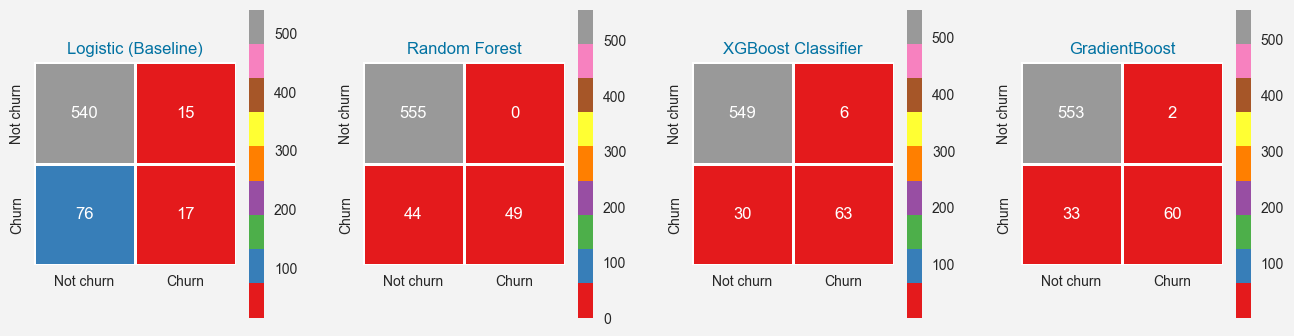

In [191]:
confmatplot(modeldict=models, df_train=x_train, df_test=x_test, 
             target_train=y_train, target_test=y_test, figcolnumber=4)

## <a id='5.4'>5.4. ROC - Curves  for models</a>

In [192]:
def rocplot(modeldict, df_train, df_test, target_train, target_test, figcolnumber):
	fig = plt.figure(figsize=(4*figcolnumber, 4*ceil(len(modeldict)/figcolnumber)))
	fig.set_facecolor("#F3F3F3")
	for name, figpos in itertools.zip_longest(modeldict, range(len(modeldict))):
		qx = plt.subplot(ceil(len(modeldict)/figcolnumber), figcolnumber, figpos+1)
		model = modeldict[name][0].fit(df_train[modeldict[name][1]], target_train)
		probabilities = model.predict_proba(df_test[modeldict[name][1]])
		predictions = model.predict(df_test[modeldict[name][1]])
					
		fpr, tpr, thresholds = roc_curve(target_test, probabilities[:,1])
		plt.plot(fpr, tpr, linestyle = "dotted",
					color = "royalblue", linewidth = 2,
					label = "AUC = " + str(np.around(roc_auc_score(target_test, predictions), 3)))
		plt.plot([0,1],[0,1], linestyle = "dashed",
					color = "orangered", linewidth = 1.5)
		plt.fill_between(fpr, tpr, alpha = .1)
		plt.fill_between([0, 1], [0, 1], color = "b")
		plt.legend(loc = "lower right",
					prop = {"size" : 12})
		qx.set_facecolor("w")
		plt.grid(True, alpha = .15)
		plt.title(name, color = "b")
		plt.xticks(np.arange(0, 1, .3))
		plt.yticks(np.arange(0, 1, .3))

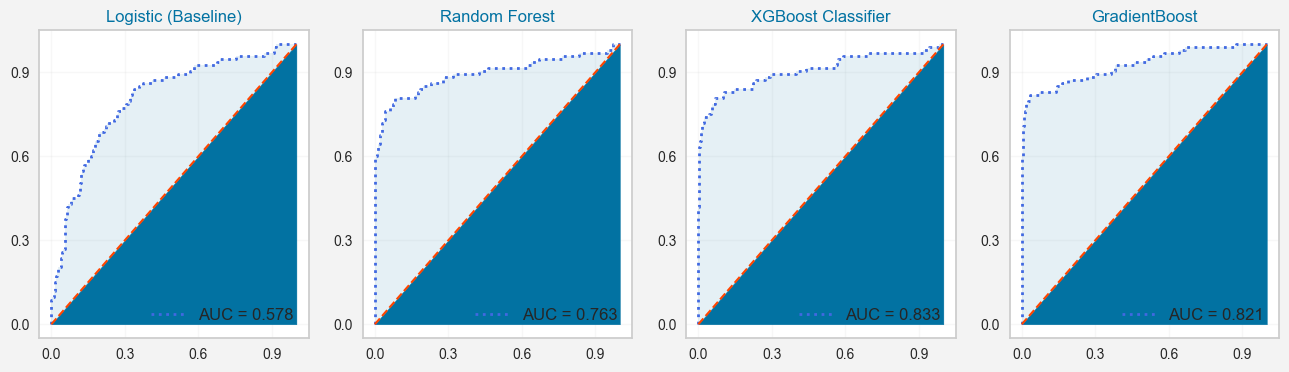

In [193]:
rocplot(modeldict=models, df_train=x_train, df_test=x_test, 
             target_train=y_train, target_test=y_test, figcolnumber=4)

## <a id='5.5'>5.5. Precision recall curves</a>

In [194]:
def prcplot(modeldict, df_train, df_test, target_train, target_test, figcolnumber):
	fig = plt.figure(figsize=(4*figcolnumber, 4*ceil(len(modeldict)/figcolnumber)))
	fig.set_facecolor("#F3F3F3")
	for name, figpos in itertools.zip_longest(modeldict, range(len(modeldict))):
		qx = plt.subplot(ceil(len(modeldict)/figcolnumber), figcolnumber, figpos+1)
		model = modeldict[name][0].fit(df_train[modeldict[name][1]], target_train)
		probabilities = model.predict_proba(df_test[modeldict[name][1]])
		predictions = model.predict(df_test[modeldict[name][1]])

		recall, precision, thresholds = precision_recall_curve(target_test, probabilities[:,1])
		plt.plot(recall, precision, linewidth = 1.5,
					label = ("avg_pcn: "+str(np.around(average_precision_score(target_test, predictions), 3))))
		plt.plot([0, 1], [0, 0], linestyle = "dashed")
		plt.fill_between(recall, precision, alpha = .1)
		plt.legend(loc = "lower left", prop = {"size": 10})
		qx.set_facecolor("w")
		plt.grid(True, alpha = .15)
		plt.title(name, color = "b")
		plt.xlabel("recall", fontsize=7)
		plt.ylabel("precision", fontsize=7)
		plt.xlim([0.25,1])
		plt.yticks(np.arange(0, 1, .3))

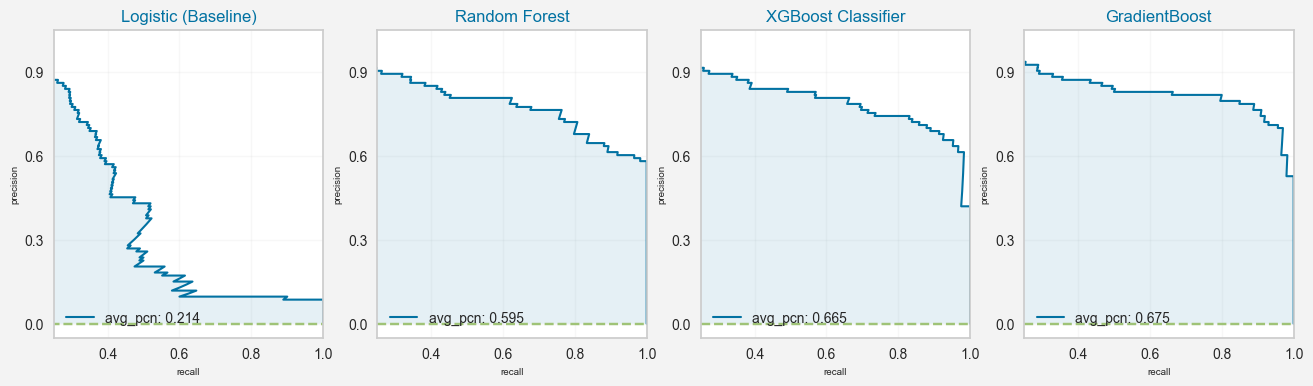

In [195]:
prcplot(modeldict=models, df_train=x_train, df_test=x_test, 
             target_train=y_train, target_test=y_test, figcolnumber=4)

# <a id='6'>6. Model performances over the principal test dataset</a>
## <a id='6.1'>6.1. Model performance metrics</a>

In [196]:
# outputs for all models over the principal test dataset
model_performances_test = []

for name in models:
    model_results = model_report(
        models[name][0], 
        x_train[models[name][1]], 
        telcom_test[models[name][1]], 
        y_train, 
        telcom_test[target_col], 
        name
    )
    model_performances_test.append(model_results)

# Convertimos la lista a DataFrame
model_performances_test = pd.DataFrame(model_performances_test)

# Crear tabla con Plotly
import plotly.figure_factory as ff
import plotly.offline as py
table_test = ff.create_table(np.round(model_performances_test, 4))
py.iplot(table_test)


In [201]:
model_performances_test

,Model,Accuracy,Precision,Recall,f1-score,Roc_auc
0,Logistic (Baseline),0.851852,0.814573,0.851852,0.822996,0.811640
1,Random Forest,0.936728,0.937359,0.936728,0.930263,0.917579
2,XGBoost Classifier,0.953704,0.952422,0.953704,0.951827,0.915995
3,GradientBoost,0.950617,0.950793,0.950617,0.947118,0.926865


## <a id='6.2'>6.2. Compare model metrics</a>

In [197]:
modelmetricsplot(df=model_performances_test, title="Model performances over the principal test dataset")

## <a id='6.3'>6.3. Confusion matrices for models</a>

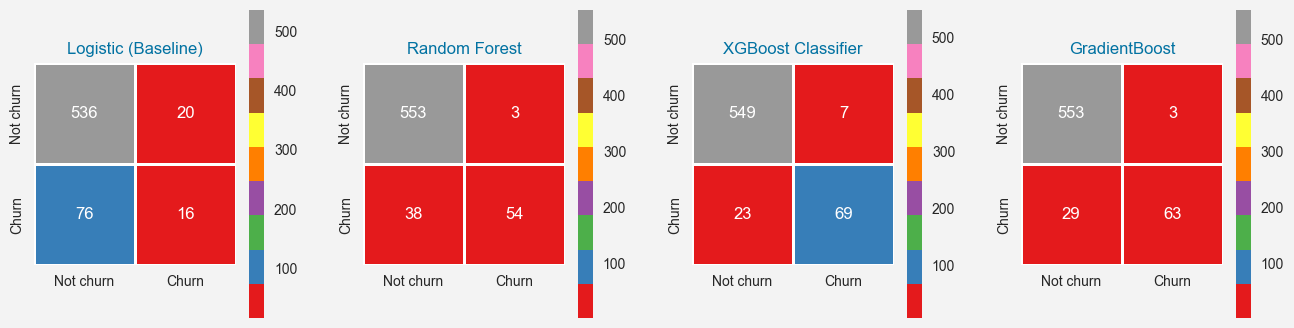

In [198]:
confmatplot(modeldict=models, df_train=x_train, df_test=telcom_test[cols], 
             target_train=y_train, target_test=telcom_test[target_col], figcolnumber=4)

## <a id='6.4'>6.4. ROC - Curves for models</a>

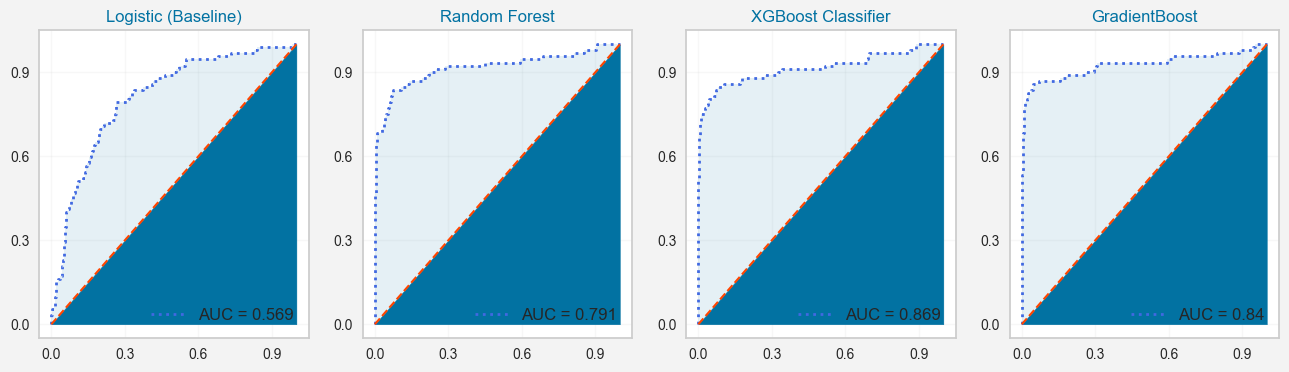

In [199]:
rocplot(modeldict=models, df_train=x_train, df_test=telcom_test[cols], 
             target_train=y_train, target_test=telcom_test[target_col], figcolnumber=4)

## <a id='6.5'>6.5. Precision recall curves</a>

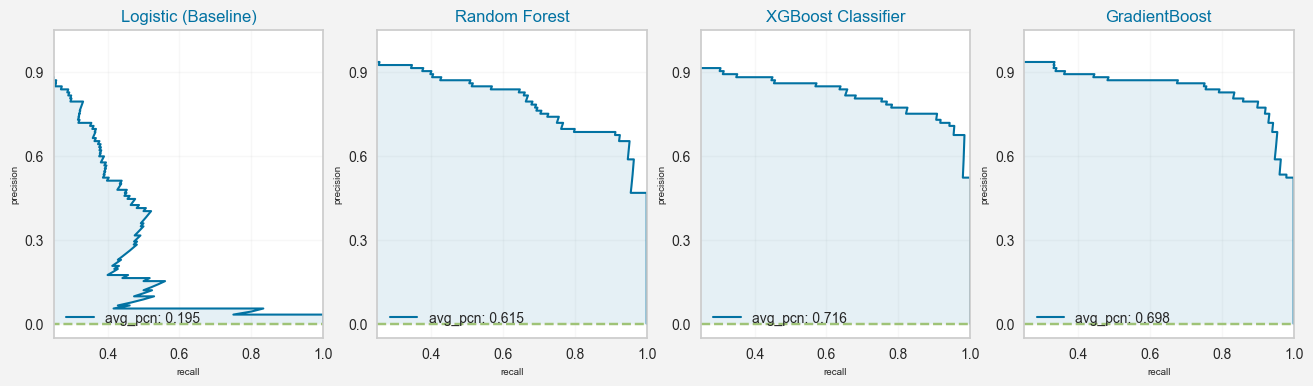

In [200]:
prcplot(modeldict=models, df_train=x_train, df_test=telcom_test[cols], 
             target_train=y_train, target_test=telcom_test[target_col], figcolnumber=4)

# <a id='1'>7. Conclusion</a>
- Logistic Regression (Baseline): 
  - El modelo tiene un buen desempeño para ser un modelo simple, pero queda atrás frente a los modelos de árbol.
  - F1 y AUC ligeramente menores que los de los demás.
- Random Forest:
	- Muy buen rendimiento, consistente entre train y test.
	- F1 0.9229 en train y 0.9303 en test lo que implica buena generalización.
- XGBoost Classifier:
	- Excelente Accuracy y F1 en test (0.9537 y 0.9518).
	- AUC ligeramente menor en test respecto al train (0.9056 vs 0.9160), pero sigue siendo robusto.
- GradientBoost:
	- Muy alto rendimiento en train (Accuracy 0.9460, F1 0.9413, AUC 0.9259).
	- En test, F1 ligeramente menor que XGBoost (0.9471 vs 0.9518), pero mejor AUC (0.9269).
	- Buen balance entre predicción correcta (Accuracy/F1) y capacidad de discriminación (AUC).
  

Todos los modelos muestran buen comportamiento y no hay sobreajuste significativo. El mejor modelo según AUC en test es el GradientBoost; sin embargo, según F1 y Accuracy en test el mejor modelo es XGBoost Classifier con el cual nos quedaremos ya que tiene una mejor clasificación.